# Notebook 01 : Validation Théorique du Modèle Binomial (CRR)

## 1. Objectif du Notebook
Avant d'appliquer notre pricer sur des données de marché réelles, nous devons valider sa robustesse mathématique sur des données synthétiques. 
Nous allons :
1. Comparer le prix du **Call/Put Européen** issu de l'arbre binomial avec la formule exacte de **Black-Scholes**.
2. Démontrer l'existence de la **prime d'exercice anticipé** pour une option Américaine.
3. Analyser la **convergence** de l'algorithme en fonction du nombre de pas ($N$).

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Ajout du dossier source au path pour importer nos modules
sys.path.append(os.path.abspath('../'))
from src.models.binomial_tree import crr_pricing

# Configuration graphique
sns.set_theme(style="whitegrid")

## 2. Le Benchmark Analytique : Formule de Black-Scholes
Pour valider l'arbre européen, nous avons besoin de la vraie valeur théorique. Définissons rapidement la formule fermée de Black-Scholes pour s'en servir de "vérité terrain".

In [2]:
def black_scholes_analytical(S, K, T, r, vol, q=0.0, is_put=False):
    """Calcule le prix exact d'une option européenne via Black-Scholes."""
    d1 = (np.log(S / K) + (r - q + 0.5 * vol**2) * T) / (vol * np.sqrt(T))
    d2 = d1 - vol * np.sqrt(T)
    
    if not is_put:  # Call
        price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:           # Put
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    return price

# Paramètres de test (Option dans la monnaie)
params = {
    "S": 100.0,
    "K": 100.0,
    "vol": 0.20,  # 20%
    "r": 0.05,    # Correction : "rate" devient "r"
    "q": 0.0,     # Correction : "div" devient "q"
    "T": 1.0      # 1 an
}

bs_call = black_scholes_analytical(**params, is_put=False)
bs_put = black_scholes_analytical(**params, is_put=True)

print(f"Black-Scholes - Call : {bs_call:.4f} €")
print(f"Black-Scholes - Put  : {bs_put:.4f} €")

Black-Scholes - Call : 10.4506 €
Black-Scholes - Put  : 5.5735 €


## 3. Validation de l'Arbre CRR (Option Européenne)
Testons maintenant notre algorithme vectorisé de Cox-Ross-Rubinstein avec $N = 1000$ pas.

In [3]:
n_steps = 1000

crr_call_eur = crr_pricing(
    S=params["S"], K=params["K"], vol=params["vol"], 
    rate=params["r"], div=params["q"], T=params["T"], 
    n_steps=n_steps, is_put=False, is_american=False
)

crr_put_eur = crr_pricing(
    S=params["S"], K=params["K"], vol=params["vol"], 
    rate=params["r"], div=params["q"], T=params["T"], 
    n_steps=n_steps, is_put=True, is_american=False
)

print("--- COMPARAISON EUROPÉENNE (CRR vs BS) ---")
print(f"Call CRR : {crr_call_eur:.4f} € | Call BS : {bs_call:.4f} € | Erreur : {abs(crr_call_eur - bs_call):.6f} €")
print(f"Put CRR  : {crr_put_eur:.4f} € | Put BS  : {bs_put:.4f} € | Erreur : {abs(crr_put_eur - bs_put):.6f} €")

--- COMPARAISON EUROPÉENNE (CRR vs BS) ---
Call CRR : 10.4486 € | Call BS : 10.4506 € | Erreur : 0.001999 €
Put CRR  : 5.5715 € | Put BS  : 5.5735 € | Erreur : 0.001999 €


## 4. Évaluation de l'Option Américaine
Nous activons le flag `is_american=True`. Pour rappel, un Put américain sans dividende devrait toujours avoir une prime d'exercice anticipé positive face à un environnement de taux d'intérêt positif.

In [4]:
crr_put_ame = crr_pricing(
    S=params["S"], K=params["K"], vol=params["vol"], 
    rate=params["r"], div=params["q"], T=params["T"], 
    n_steps=n_steps, is_put=True, is_american=True
)

print("--- PRIME D'EXERCICE ANTICIPÉ (PUT) ---")
print(f"Put Européen (CRR) : {crr_put_eur:.4f} €")
print(f"Put Américain (CRR): {crr_put_ame:.4f} €")
print(f"=> Prime Américaine: {crr_put_ame - crr_put_eur:.4f} €")

--- PRIME D'EXERCICE ANTICIPÉ (PUT) ---
Put Européen (CRR) : 5.5715 €
Put Américain (CRR): 6.0896 €
=> Prime Américaine: 0.5181 €


## 5. Analyse de la Convergence et Oscillations
L'un des défauts connus du modèle CRR est son oscillation numérique lorsque le nombre de pas $N$ est faible et que le Strike tombe entre deux nœuds finaux. 
Visualisons cette convergence vers le prix de Black-Scholes.

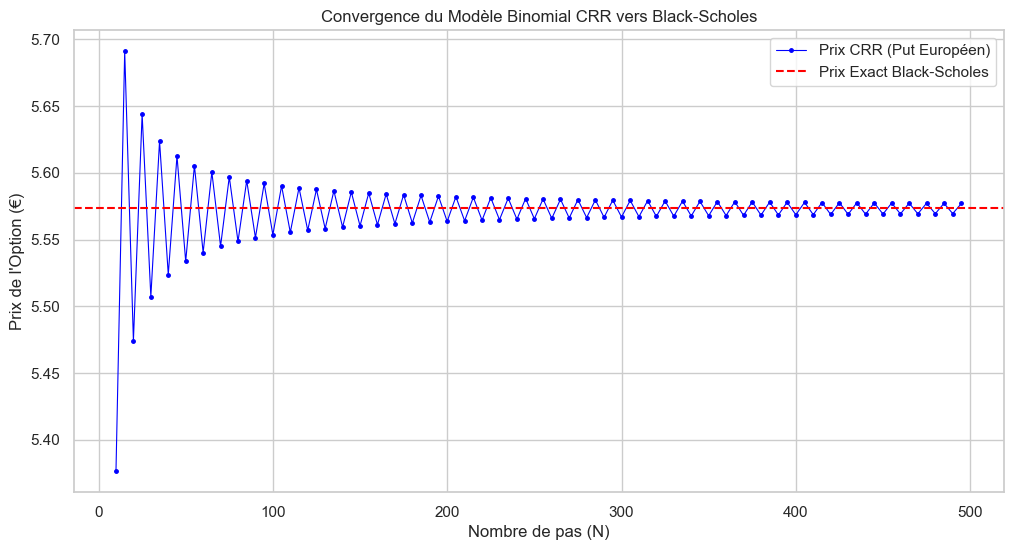

In [5]:
steps_range = range(10, 500, 5)
crr_prices = []

# On calcule le prix CRR pour chaque N
for n in steps_range:
    p = crr_pricing(
        S=params["S"], K=params["K"], vol=params["vol"], 
        rate=params["r"], div=params["q"], T=params["T"], 
        n_steps=n, is_put=True, is_american=False
    )
    crr_prices.append(p)

plt.figure(figsize=(12, 6))
plt.plot(steps_range, crr_prices, label="Prix CRR (Put Européen)", color="blue", marker=".", markersize=5, linestyle="-", linewidth=0.8)
plt.axhline(y=bs_put, color="red", linestyle="--", label="Prix Exact Black-Scholes")

plt.title("Convergence du Modèle Binomial CRR vers Black-Scholes")
plt.xlabel("Nombre de pas (N)")
plt.ylabel("Prix de l'Option (€)")
plt.legend()
plt.show()

### Interprétation Graphique
* **L'oscillation en "dents de scie"** est très visible pour des $N$ faibles (entre 10 et 100 pas). C'est la signature classique du modèle de Cox-Ross-Rubinstein liée aux effets de parité (selon que $N$ est pair ou impair, le prix final tombe exactement sur le Strike ou autour).
* **La convergence** : À mesure que $N \to \infty$, l'amplitude des oscillations diminue et le prix CRR tend parfaitement vers le prix analytique de Black-Scholes, validant l'exactitude de notre implémentation mathématique.